## Time series analysis of lateral velocity:
This notebook analyses the variation in lateral velocity, $`u_y`$, over time to detect von Kármán vortex shedding and how surpression of this may contribute to reduced drag coefficient. Analysis was conducted with free stream velocity of $`0.1`$ m s $`^{-1}`$.

`time_series.csv` and `FFT.csv` files for each taxon were created manually in paraview (see `time_series_analysis.pvsm` in `[taxon]/velocity/v0.1/postProcessing/`).

In [ ]:
#import libraries:
import numpy as np
import paraview
import glob
import os
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import csv
import gc

In [60]:
# Defining functions:
def U_read(taxon, file): # Reads in velocity data from paraview, converts to cm/s and returns as array.
    dir = '../' + taxon +'/velocity/v0.1/postProcessing/'
    with open(dir + file) as f:
        #row_count = sum(1 for row in f)
        U = []
        u = []
        v = []
        w = []
        minv = []
        q1v = []
        q3v = []
        maxv = []

        reader = csv.DictReader(f, delimiter=',')
        for row in reader:
            U.append(float(row['avg(U (Magnitude))']))  # Access by column header instead of column number
            u.append(float(row['avg(U (0))']))  
            v.append(float(row['avg(U (1))']))
            w.append(float(row['avg(U (2))']))
            minv.append(float(row['min(U (1))']))  
            maxv.append(float(row['max(U (1))']))
            q1v.append(float(row['q1(U (1))']))  
            q3v.append(float(row['q3(U (1))']))

            
        U = np.array(U)
        u = np.array(u)
        v = np.array(v)
        w = np.array(w)
        minv = np.array(minv)
        maxv = np.array(maxv)
        q1v = np.array(q1v)
        q3v = np.array(q3v)
        
        #x = x*100  #convert to cm
        #Umag = np.sqrt((u**2)+(v**2)+(w**2))*1000
        #print(Umag.shape)
        U_final = np.array((U*100,u*100,v*100,w*100,minv*100,q1v*100,q3v*100,maxv*100))#Umag
        
        return U_final

def FFT_read(taxon, file, L):
    # Reads in FFT data from paraview, removes negative frequencies and computes Strouhal number based
    # on characteristic length provided, assuming free stream velocity of 0.1m/s.
    dir = '../' + taxon +'/velocity/v0.1/postProcessing/'
    with open(dir + file) as f:
        freq = []
        Fx = []
        Fy = []

        reader = csv.DictReader(f, delimiter=',')
        for row in reader:
            freq.append(float(row['Frequency']))  # Access by column header instead of column number
            Fx.append(float(row['avg(U (1)):0']))  
            Fy.append(float(row['avg(U (1)):1']))  

        freq = np.array(freq)
        Fx = np.array(Fx)
        Fy = np.array(Fy)
        F = np.sqrt(Fx**2 + Fy**2) 
        # removing -ve frequencies
        freq_pos = freq[freq >= 0]
        F_pos = F[:len(freq_pos)]

        # Strouhal number: St = f*L/U
        U = 0.1 # free stream velocity
        strouhal = freq_pos*L/U
        
        FFT_final = np.array((strouhal,F_pos))#Umag
        
        return FFT_final

def plot(taxon1, taxon2, time_series1, time_series2, FFT1, FFT2): # Plots time series and FFT data for two taxa side by side.
    t = np.arange(0,41,1)
    fig, axs = plt.subplots(1, 2, figsize=(8, 4), dpi=300, gridspec_kw={'width_ratios':[2,1]})
    axs[0].plot(t, time_series1[2], linewidth=1, color='#1F8741', label=taxon1, alpha=0.4)
    axs[0].plot(t, time_series2[2], linestyle = '--', linewidth=1, color='#9C0976', label=taxon2, alpha=0.4)
    axs[0].fill_between(t, time_series1[5], time_series1[6], color='#1F8741', alpha=0.2)
    axs[0].fill_between(t, time_series2[5], time_series2[6], color='#9C0976', alpha=0.2)
    axs[0].set_ylabel(r'u$_y$ (cm/s)')
    axs[0].set_xlabel(r't (s)')
    axs[0].xaxis.set_major_locator(plt.MaxNLocator(integer=True))

    # create custom linestyle legend entries
    solid_handle = Line2D([0], [0], color='#1F8741', linestyle='-', linewidth=1, alpha=0.8)
    dashed_handle = Line2D([0], [0], color='#9C0976', linestyle='--', linewidth=1, alpha=0.8)

    fig.legend(
        [solid_handle, dashed_handle],
        [taxon1, taxon2],
        loc=1,
        bbox_to_anchor=(0.32, 0.3),
    )
    axs[1].plot(FFT1[0], FFT1[1], linewidth=1, color='#1F8741', label=taxon1)
    axs[1].plot(FFT2[0], FFT2[1], linestyle = '--', linewidth=1, color='#9C0976', label=taxon2)
    axs[1].set_xlabel('Strouhal Number')
    axs[1].set_ylabel(r'FFT of u$_y$ (cm/s)')
    axs[1].tick_params(axis='both', which='major', labelsize=8)
    fig.tight_layout()


### Edrioasteroids

(41,)


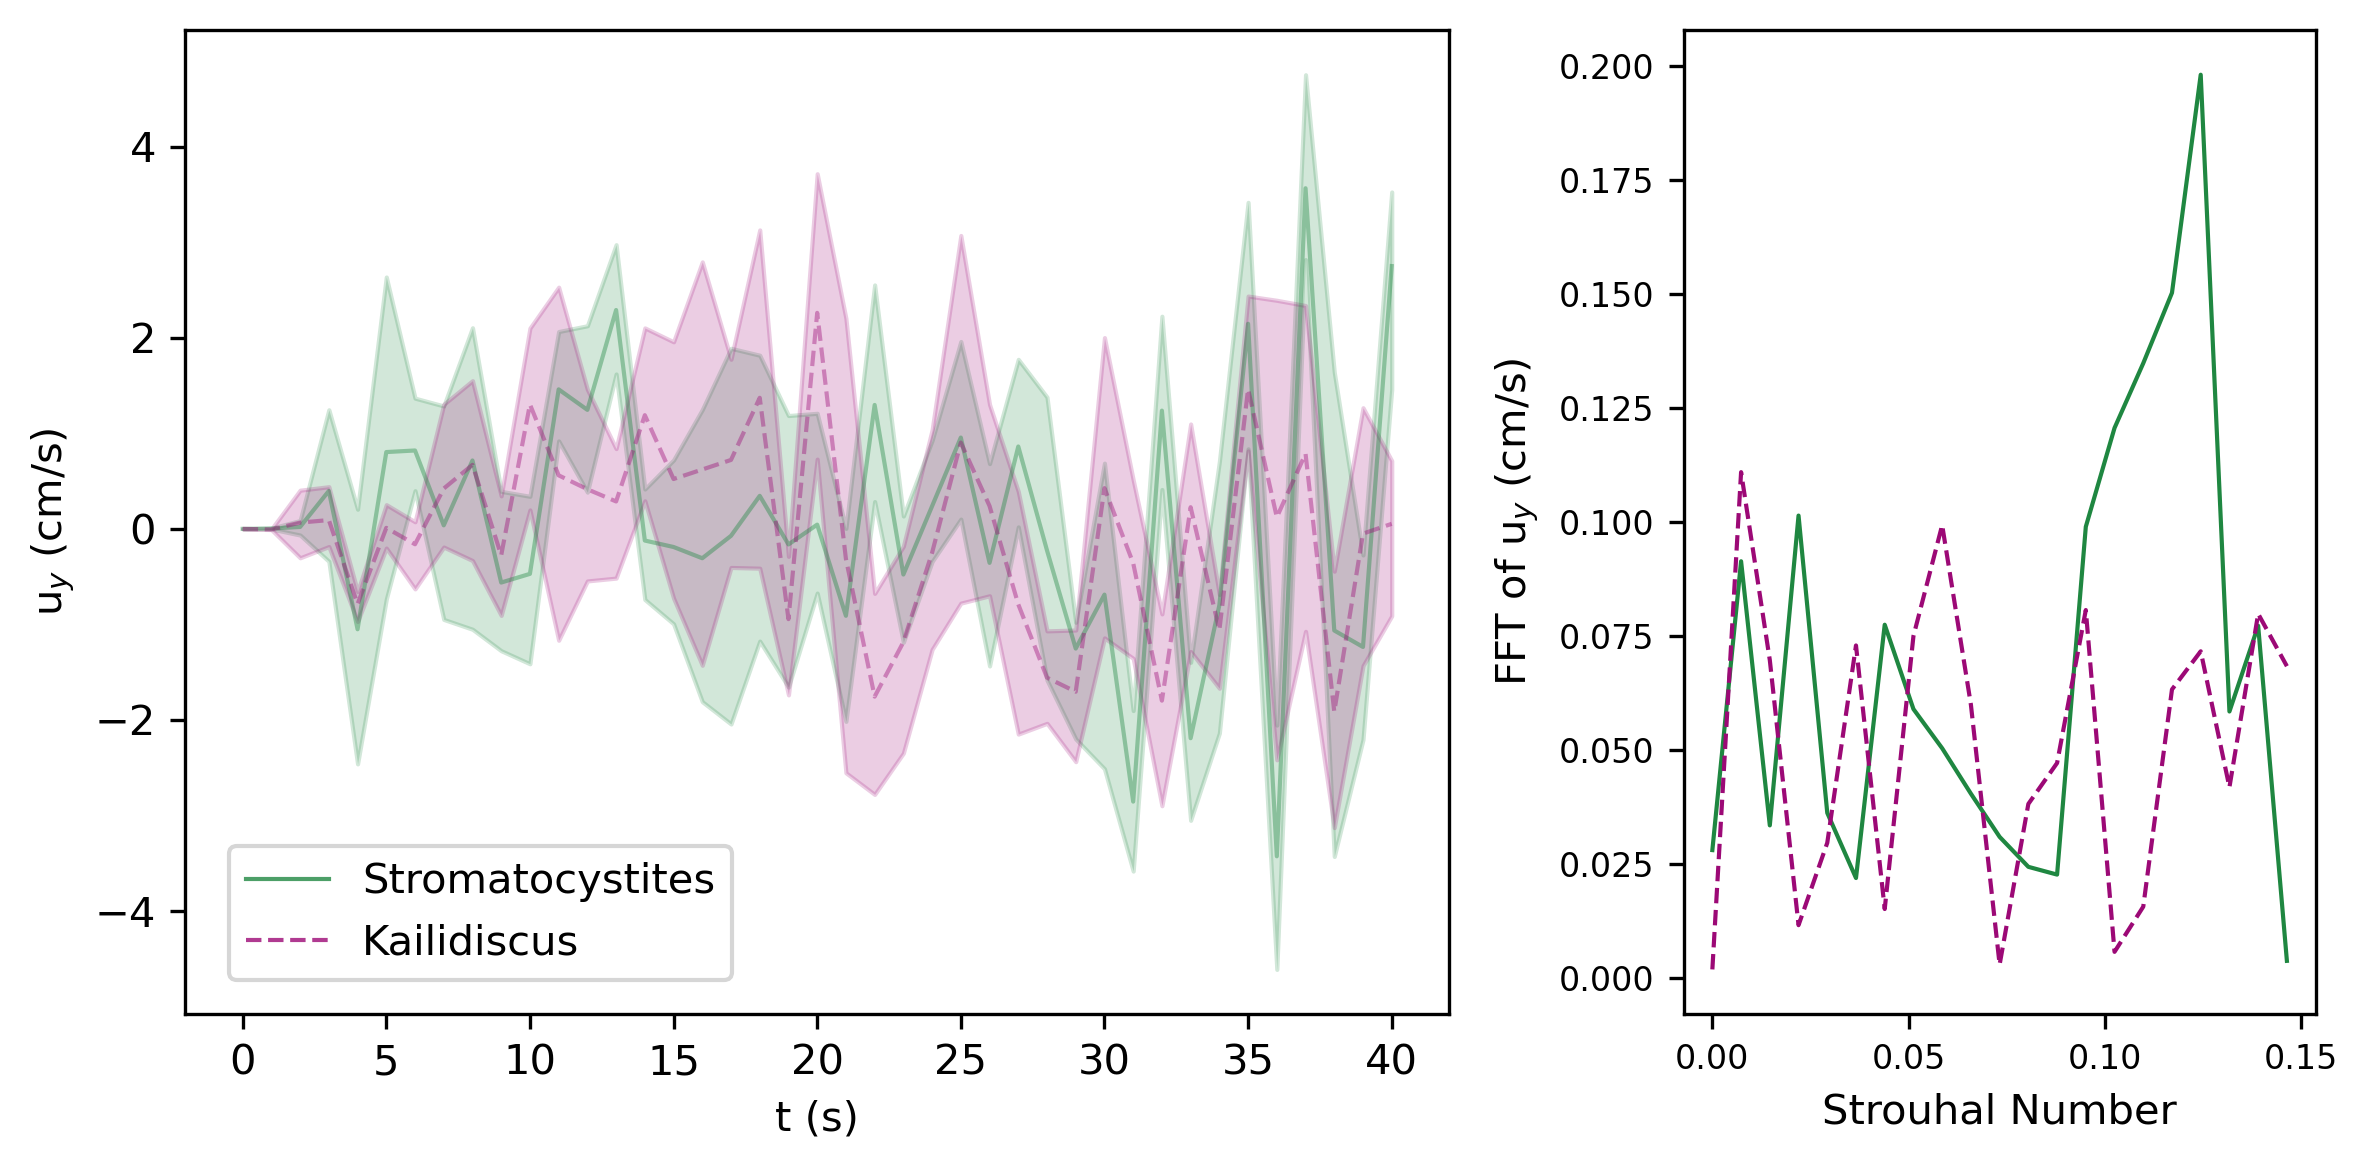

In [ ]:
time_series_stromat = U_read('stromatocystites', 'time_series.csv')
time_series_kaili = U_read('kailidiscus', 'time_series.csv')
FFT_stromat = FFT_read('stromatocystites', 'FFT.csv', 0.03)
FFT_kaili = FFT_read('kailidiscus', 'FFT.csv', 0.03)
plot('Stromatocystites', 'Kailidiscus', time_series_stromat, time_series_kaili, FFT_stromat, FFT_kaili)
plt.savefig('time_series_edrioasteroids.pdf', dpi=300)

### Helicocystis:

In [57]:
time_series_helico = U_read('helicocystis', 'time_series.csv')
time_series_helico_straight = U_read('helicocystis_straight', 'time_series.csv')
FFT_helico = FFT_read('helicocystis', 'FFT.csv', 0.03)
FFT_helico_straight = FFT_read('helicocystis_straight', 'FFT.csv', 0.03)
plot('Helicocystis', 'Helicocystis_straight', time_series_helico, time_series_helico_straight, FFT_helico, FFT_helico_straight)
plt.savefig('time_series_helicocystis.pdf', dpi=300)

FileNotFoundError: [Errno 2] No such file or directory: '../helicocystis/velocity/v0.1/postProcessing/time_series.csv'

### Gogiids:

(41,)


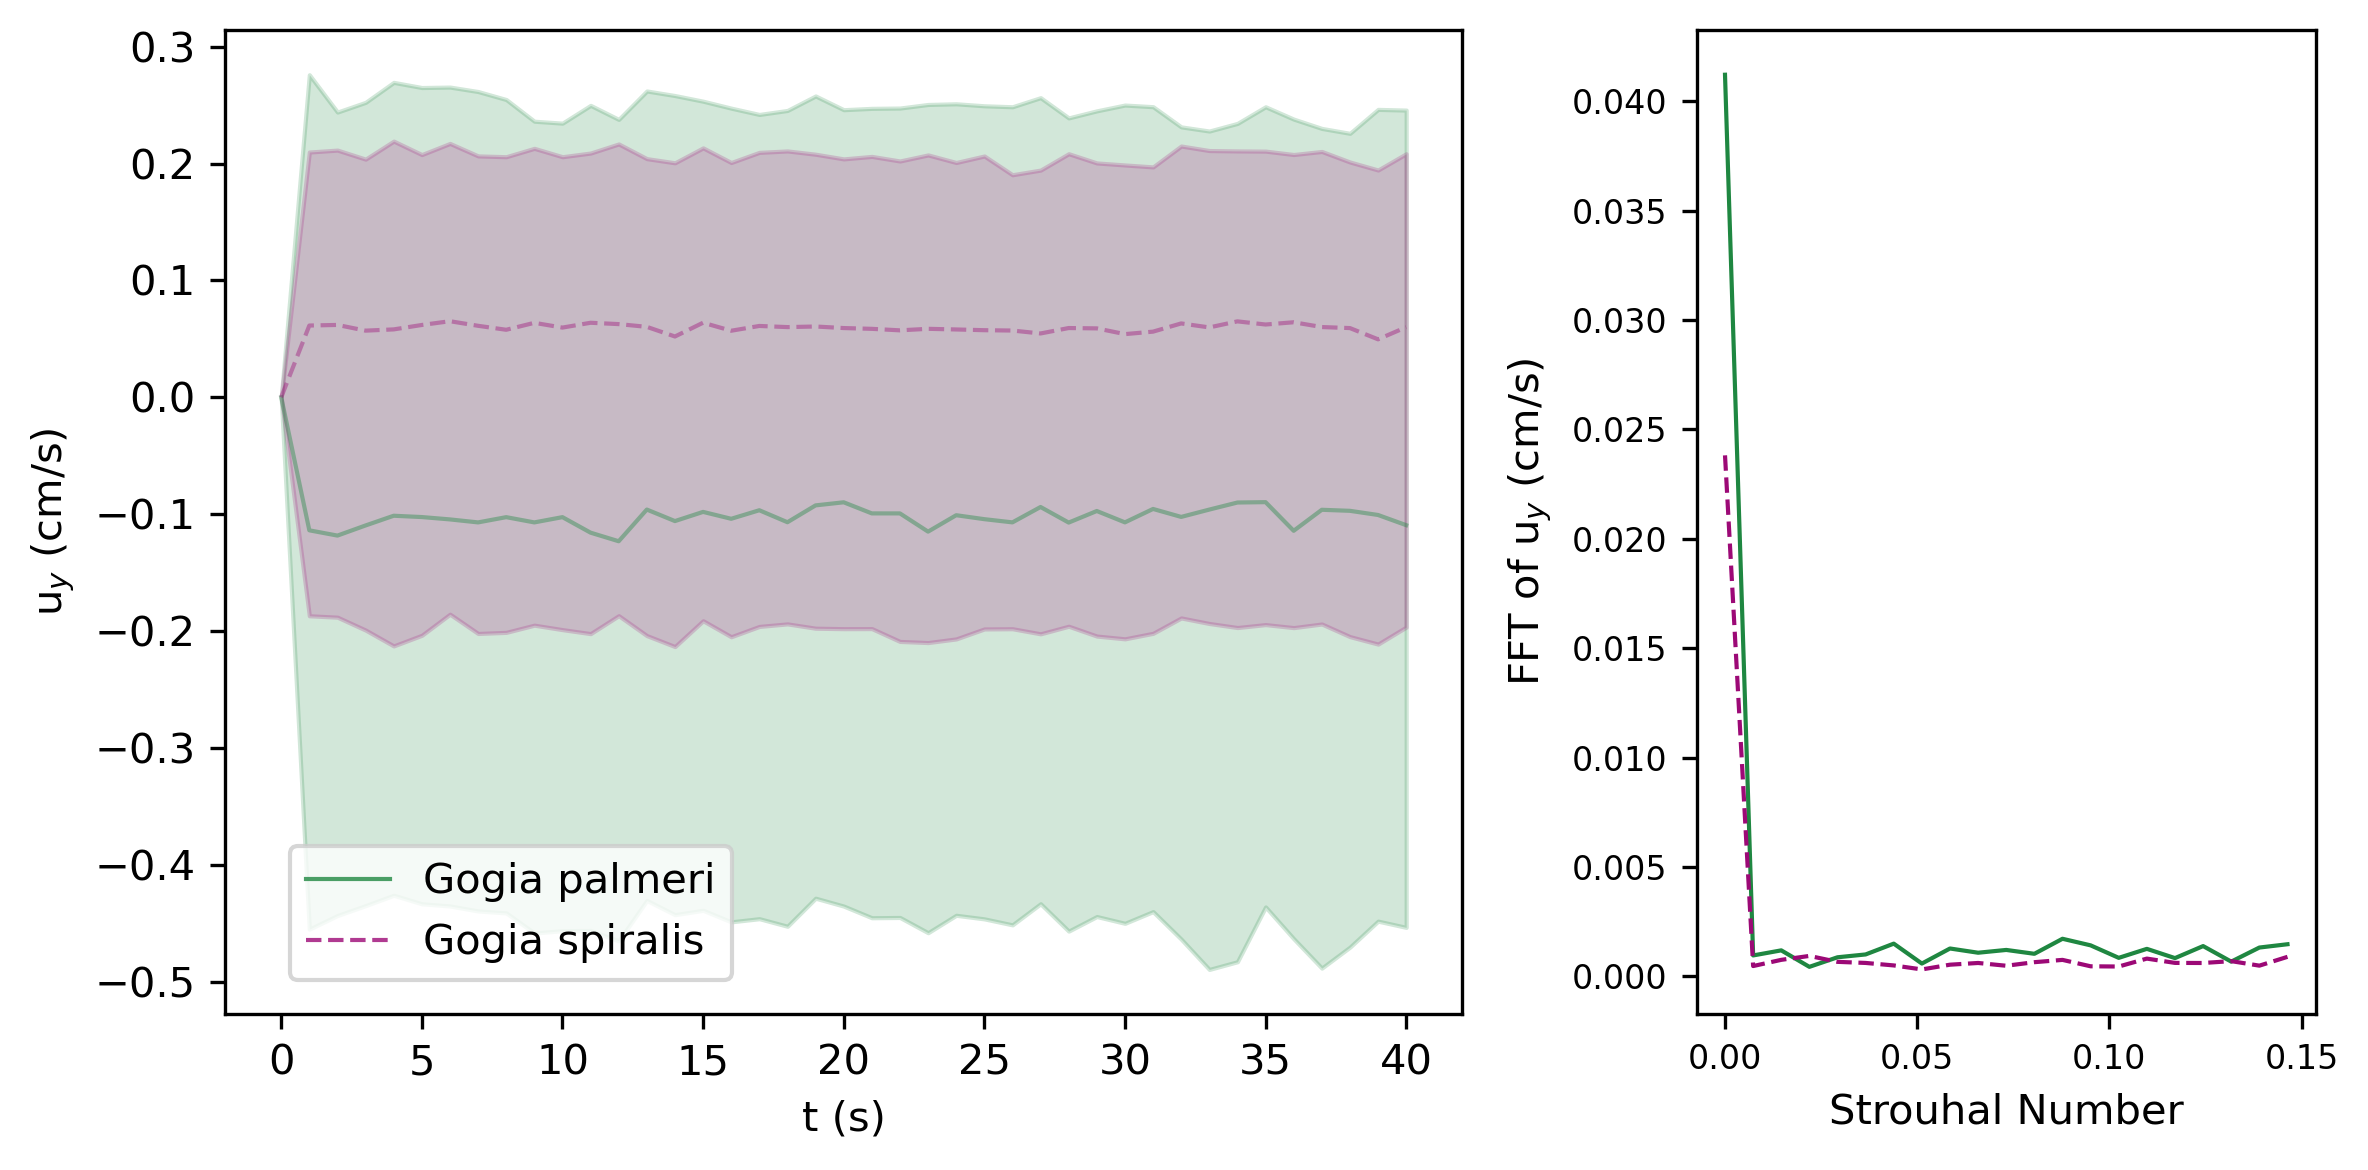

In [58]:
time_series_palmeri = U_read('gogia_palmeri', 'time_series.csv')
time_series_spiralis = U_read('gogia_spiralis', 'time_series.csv')
FFT_palmeri = FFT_read('gogia_palmeri', 'FFT.csv', 0.03)
FFT_spiralis = FFT_read('gogia_spiralis', 'FFT.csv', 0.03)
plot('Gogia palmeri', 'Gogia spiralis', time_series_palmeri, time_series_spiralis, FFT_palmeri, FFT_spiralis)
plt.savefig('time_series_gogiids.pdf', dpi=300)